In [2]:
import pandas as pd

In [ ]:
# ## ----- the directory convention used is based off the google drive organization ------ ##

In [20]:
# rheo_df = pd.read_excel("/Users/mauriellenoto/Desktop/seager/ionicliquids/isn/UAFW/UAFW_20260707_rheo.xls")

import pandas as pd
tga_df = pd.read_excel('/Users/mauriellenoto/Desktop/seager/ionicliquids/isn/TGA/2026-07-13/2026-07-13-TGA-UAFW.xls',
                       sheet_name=None)
tga_df = pd.read_excel('/Users/mauriellenoto/Desktop/seager/ionicliquids/isn/TGA/2026-07-13/2026-07-13-TGA-UAFW.xls',
                       sheet_name="Ramp 10.00 °Cmin to 650.00 °C", header=1)
cols = list(tga_df.columns)
tga_df
# print(type(cols))
# sheets = list(tga_df.keys())

# data = sheets[1:]
# sheets


,Time,Temperature,Weight,Weight.1,Deriv. Weight
0,min,°C,mg,%,% / °C
1,0.01,22.81,7.316,100.077,-0.347624
2,0.02,22.81,7.325,100.2,-0.347624
3,0.04,22.81,7.327,100.224,-0.347624
4,0.06,22.81,7.327,100.23,-0.347624
...,...,...,...,...,...
3773,62.87,647.12,0.002,0.031,0.001184
3774,62.89,647.29,0.002,0.031,0.001186
3775,62.91,647.45,0.002,0.032,0.001187
3776,62.92,647.62,0.002,0.032,0.001189


In [22]:

# if you want a df of the details, use:
# details_df = pd.read_excel("path_to_excel_file", sheet_name = "Details", header = 1)

def extract_data(path): 
    # Read in original file 
    xl = pd.ExcelFile(path) 
    all_sheets = xl.sheet_names 
    print(all_sheets) 
    
    data_sheets = all_sheets[1:] 
    df_list = [] 
    
    for sheet in data_sheets: 
        sheet_df = pd.read_excel(path, sheet_name=sheet, header=1) 
        
        # extract the units from the first row of data (index 0)
        units = sheet_df.iloc[0].fillna('').astype(str).tolist()
        
        # combine old column names with the units
        new_columns = []
        for col, unit in zip(sheet_df.columns, units):
            clean_col = col.split('.')[0] if '.' in col else col
            if unit:
                new_columns.append(f"{clean_col} ({unit})")
            else:
                new_columns.append(clean_col)
                
        # assign the new combined names back to the dataframe columns
        sheet_df.columns = new_columns
        
        # drop units row from the data
        sheet_df = sheet_df.drop(index=0).reset_index(drop=True)
        
        # add source sheet column
        sheet_df['Source Sheet'] = sheet 
        df_list.append(sheet_df) 
        
    # Vertically stack all the sheets together into one final df 
    combined_df = pd.concat(df_list, ignore_index=True)
    
    # convert to float
    # errors='coerce' turns any unconvertible text or bad data into NaN safely
    for col in combined_df.columns:
        if col != 'Source Sheet':
            combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')
    
    # make sure source sheet is last column in final df
    cols = [col for col in combined_df.columns if col != 'Source Sheet'] + ['Source Sheet']
    combined_df = combined_df[cols]
    
    return combined_df

data_df = extract_data('/Users/mauriellenoto/Desktop/seager/ionicliquids/isn/TGA/2026-07-13/2026-07-13-TGA-UAFW.xls')
data_df.head()

['Details', 'Ramp 10.00 °Cmin to 650.00 °C', 'Equilibrate 30.00 °C']


,Time (min),Temperature (°C),Weight (mg),Weight (%),Deriv (% / °C),Source Sheet
0,0.01,22.81,7.316,100.077,-0.347624,Ramp 10.00 °Cmin to 650.00 °C
1,0.02,22.81,7.325,100.200,-0.347624,Ramp 10.00 °Cmin to 650.00 °C
2,0.04,22.81,7.327,100.224,-0.347624,Ramp 10.00 °Cmin to 650.00 °C
3,0.06,22.81,7.327,100.230,-0.347624,Ramp 10.00 °Cmin to 650.00 °C
4,0.07,22.81,7.327,100.232,-0.347624,Ramp 10.00 °Cmin to 650.00 °C


/var/folders/tb/m7m4hfmn3f739spxch5z3jnm0000gn/T/ipykernel_17614/2368070286.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


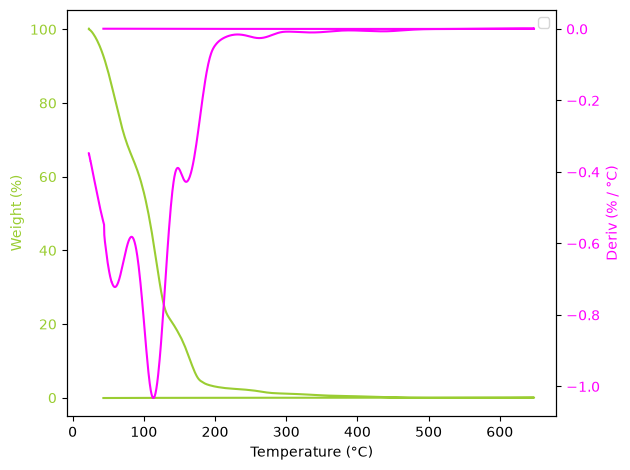

In [39]:
import matplotlib.pyplot as plt

data_cols = list(data_df.columns)

y1 = "yellowgreen"
y2 = "magenta"

fig, ax1 = plt.subplots()

ax1.plot(data_df[data_cols[1]], data_df[data_cols[3]], color = y1)
ax1.set_xlabel(data_cols[1])
ax1.set_ylabel(data_cols[3], color = y1)
ax1.tick_params(axis='y', labelcolor = y1)

ax2 = ax1.twinx()

ax2.plot(data_df[data_cols[1]], data_df[data_cols[4]], color = y2)
ax2.set_ylabel(data_cols[4], color = y2)
ax2.tick_params(axis = 'y', labelcolor = y2)

plt.legend()
plt.tight_layout()
plt.show()


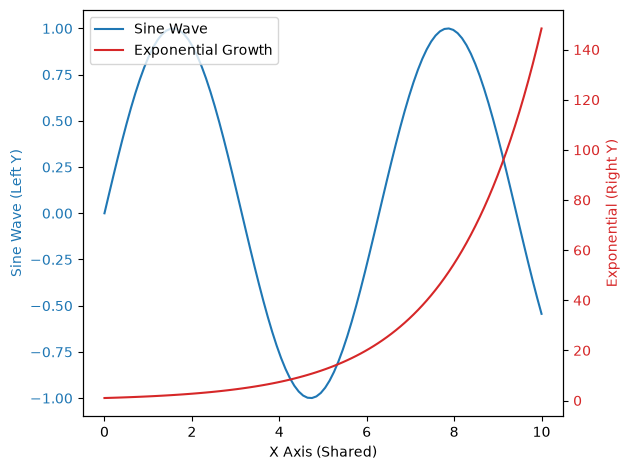

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate sample data with different scales
x = np.linspace(0, 10, 100)
y1 = np.sin(x)                 # Scale from -1 to 1
y2 = np.exp(x / 2)             # Scale from 1 to ~150

# 2. Initialize the figure and the first (primary) Y-axis
fig, ax1 = plt.subplots()

# Plot the first dataset
color_y1 = 'tab:blue'
ax1.set_xlabel('X Axis (Shared)')
ax1.set_ylabel('Sine Wave (Left Y)', color=color_y1)
line1 = ax1.plot(x, y1, color=color_y1, label='Sine Wave')
ax1.tick_params(axis='y', labelcolor=color_y1)  # Colors the tick marks

# 3. Create the second (secondary) Y-axis sharing the same X-axis
ax2 = ax1.twinx()

# Plot the second dataset
color_y2 = 'tab:red'
ax2.set_ylabel('Exponential (Right Y)', color=color_y2)
line2 = ax2.plot(x, y2, color=color_y2, label='Exponential Growth')
ax2.tick_params(axis='y', labelcolor=color_y2)  # Colors the tick marks

# 4. Correctly combine legends from both axes into a single box
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# Optimize layout and render
fig.tight_layout()
plt.show()
